In [1]:
import tensorflow as tf
import numpy as np

2026-06-10 12:51:00.739192: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781095860.955874      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781095861.022540      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781095861.570546      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781095861.570592      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781095861.570595      23 computation_placer.cc:177] computation placer alr

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 32s 0us/step


In [3]:
train_mask = np.isin(y_train, [0,1]).flatten()
test_mask = np.isin(y_test, [0,1]).flatten()

x_train = x_train[train_mask]
y_train = y_train[train_mask]

x_test = x_test[test_mask]
y_test = y_test[test_mask]

y_train = (y_train == 1).astype(int)
y_test = (y_test == 1).astype(int)

print(x_train.shape)
print(x_test.shape)

(10000, 32, 32, 3)
(2000, 32, 32, 3)


In [4]:
print(np.unique(y_train))

[0 1]


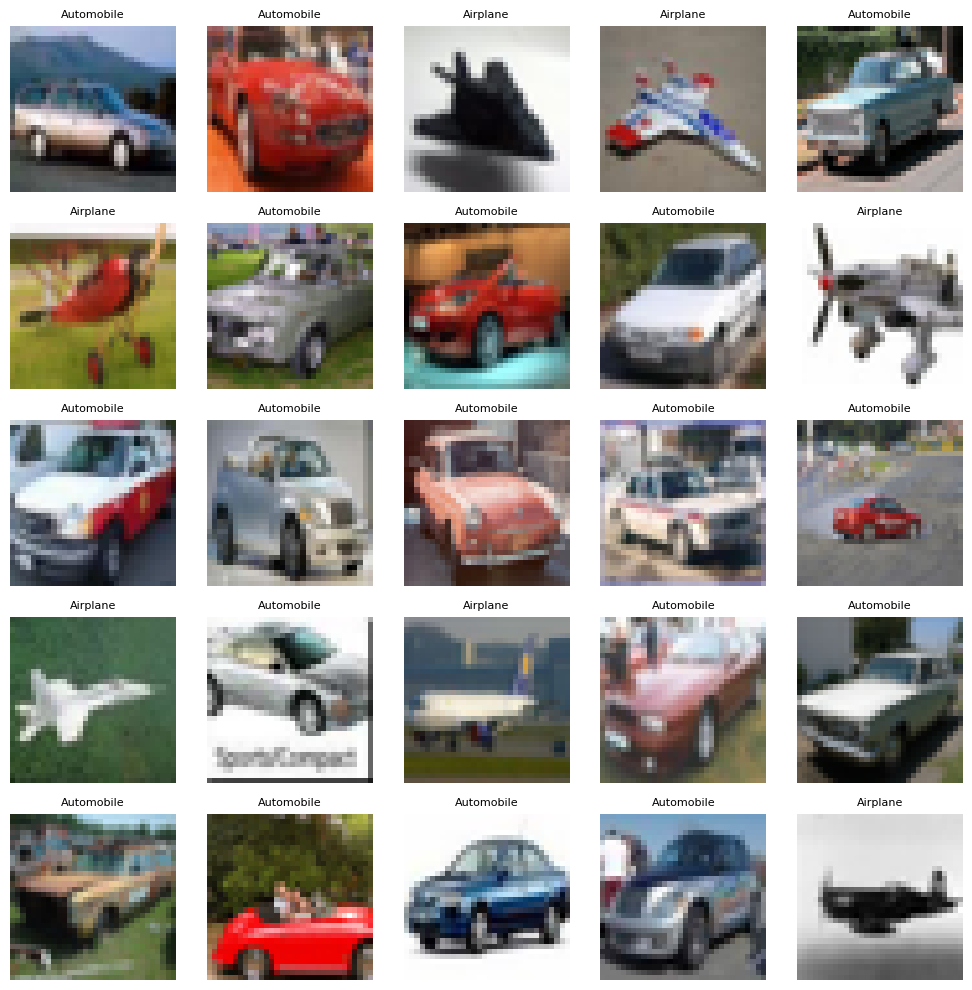

In [5]:
import matplotlib.pyplot as plt

class_names = {
    0: "Airplane",
    1: "Automobile"
}

plt.figure(figsize=(10,10))

for i in range(25):
    
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[i])
    label = class_names[int(y_train[i][0])]
    plt.title(label, fontsize=8)
    plt.axis("off")
    
plt.tight_layout()
plt.show()

In [6]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dense(
        1,
        activation='sigmoid'
    )
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1781095912.429016      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 314,561 (1.20 MB)

 Trainable params: 314,561 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [8]:
history = model.fit(
    x_train/255.0,
    y_train,
    epochs=10,
    validation_data=(x_test/255.0,y_test)
)

Epoch 1/10


I0000 00:00:1781095915.665334      69 service.cc:152] XLA service 0x79569c00b380 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781095915.665370      69 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1781095916.026831      69 cuda_dnn.cc:529] Loaded cuDNN version 91002


 59/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5798 - loss: 0.6492

I0000 00:00:1781095917.994676      69 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8245 - loss: 0.3794 - val_accuracy: 0.9065 - val_loss: 0.2262
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9085 - loss: 0.2241 - val_accuracy: 0.9310 - val_loss: 0.1818
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9275 - loss: 0.1836 - val_accuracy: 0.9325 - val_loss: 0.1748
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9361 - loss: 0.1591 - val_accuracy: 0.9405 - val_loss: 0.1522
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9489 - loss: 0.1340 - val_accuracy: 0.9445 - val_loss: 0.1423
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9580 - loss: 0.1088 - val_accuracy: 0.9475 - val_loss: 0.1470
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9633 - loss: 0.0949 - val_accuracy: 0.9500 - val_loss: 0.1552
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9714 - loss: 0.0767 - val_accuracy: 0.9365 - val

In [9]:
import matplotlib.pyplot as plt

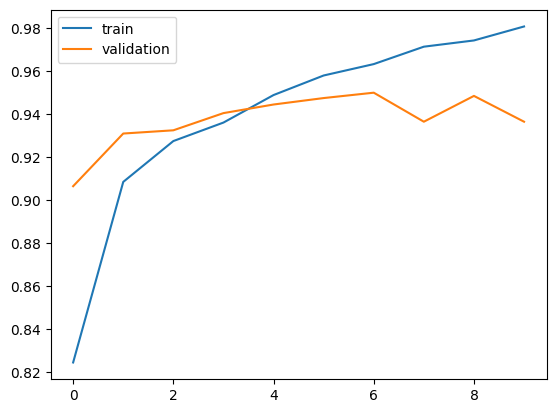

In [10]:
plt.plot(
    history.history['accuracy'],
    label='train'
)

plt.plot(
    history.history['val_accuracy'],
    label='validation'
)

plt.legend()
plt.show()

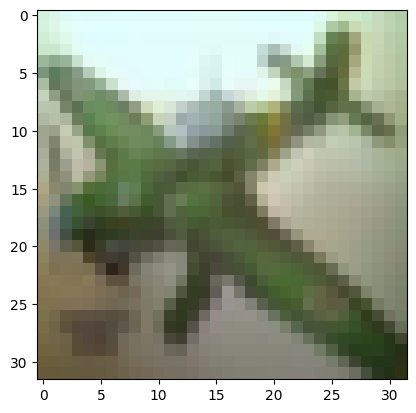

Actual Label: 0


In [11]:
import matplotlib.pyplot as plt

index = 5

plt.imshow(x_test[index])
plt.show()

print("Actual Label:", y_test[index][0])

In [12]:
img = x_test[index]

# Normalize
img = img / 255.0

# Add batch dimension
img = np.expand_dims(img, axis=0)

prediction = model.predict(img)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step
[[4.306782e-05]]


In [13]:
if prediction[0][0] > 0.5:
    print("Predicted: Automobile")
else:
    print("Predicted: Airplane")

Predicted: Airplane


In [14]:
model.save("cifar_binary_classifier.keras")

# Predict Your Own Image

In [15]:
import tensorflow as tf

Saved_model = tf.keras.models.load_model(
    "cifar_binary_classifier.keras"
)

In [16]:
from tensorflow.keras.utils import load_img
from tensorflow.keras.utils import img_to_array

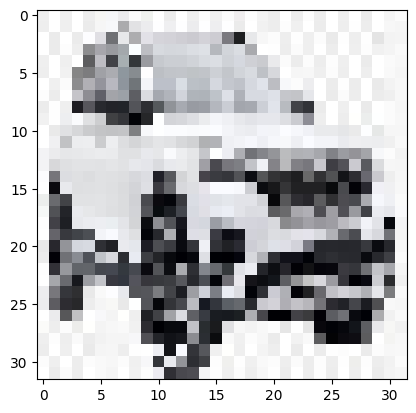

In [17]:
img = load_img(
    "/kaggle/input/datasets/ng2026/image-3/Car4.jpg",
    target_size=(32,32)
)

#"/kaggle/input/datasets/ng2026/images-2/Car3.jpg",

img_array = img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

plt.imshow(img)
plt.show()

In [18]:
prediction = Saved_model.predict(img_array)
print(prediction)

if prediction[0][0] > 0.5:
    print("Automobile")
else:
    print("Airplane")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step
[[0.7044376]]
Automobile


In [19]:
print(img_array.shape)
print(prediction)
print(img_array.min(), img_array.max())

(1, 32, 32, 3)
[[0.7044376]]
0.0 1.0
